In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

# load in dataframe with photic zone variable (using 4.5% threshold)
df = pd.read_csv("../../data/merged_dataset_organized_45photic.csv")
print(df.columns)

Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID',
       'Sta_ID', 'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line',
       'Bottom_D', 'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility',
       'PHOTIC_ZONE'],
      dtype='object')


Per 10-fold Cross Validation analysis: the photic depth threshold of 4.7% is the most viable option for calculating the photic zone depth.

The following cell calculates the new photic zone at that 4.7% threshold

In [3]:
def calculate_photic_depth_47(group):
    """Calculate depth where PAR drops to 4.7% of its value at 2m baseline."""
    group = group.sort_values('DEPTH').dropna(subset=['PAR'])
    
    depth_2m = group[group['DEPTH'] == 2.0]
    if len(depth_2m) == 0 or len(group) < 2:
        return np.nan
    
    surface_par = depth_2m['PAR'].iloc[0]
    if surface_par <= 0:
        return np.nan
    
    group = group[group['DEPTH'] >= 2.0].copy()
    group['PAR_pct'] = (group['PAR'] / surface_par) * 100
    
    above = group[group['PAR_pct'] >= 4.7]
    below = group[group['PAR_pct'] < 4.7]
    
    if len(above) == 0 or len(below) == 0:
        return np.nan
    
    d_a, d_b = above['DEPTH'].iloc[-1], below['DEPTH'].iloc[0]
    p_a, p_b = above['PAR_pct'].iloc[-1], below['PAR_pct'].iloc[0]
    
    return d_a + (d_b - d_a) * (p_a - 4.7) / (p_a - p_b)

# Drop old 4.5% photic zone column
df = df.drop(columns=['PHOTIC_ZONE'])

# Calculate photic depth (4.7% threshold) per cast
photic_zone = df.groupby('CAST_COUNT').apply(calculate_photic_depth_47, include_groups=False)
photic_zone.name = 'photic_zone'

# Merge back into df
df = df.merge(photic_zone.reset_index(), on='CAST_COUNT', how='left')

print(f"Casts with valid photic_zone: {df.groupby('CAST_COUNT')['photic_zone'].first().notna().sum()}")
print(df.groupby('CAST_COUNT')['photic_zone'].first().describe())

Casts with valid photic_zone: 1971
count    1971.000000
mean       39.542413
std        20.313460
min         3.906000
25%        24.036411
50%        36.344262
75%        51.958200
max       136.805062
Name: photic_zone, dtype: float64


The new `PHOTIC_ZONE` column contains continuous photic depth values repeated across all CTD cast depths rather than a boolean value.

The following cell writes the dataframe to a parquet (21 MB)

In [ ]:
# # write new dataset with 4.7% photic threshold as a parquet: data_47photic.parquet
# df.to_parquet('../Data/data_47photic.parquet', index=False)
# print(f"Saved to Data/data_47photic.parquet ({len(df)} rows)")

Saved to Data/data_47photic.parquet (1255966 rows)


Create elastic net using CTD variables to predict Secchi depth and perform regularization

In [12]:
print(df.columns)

Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Cast_ID',
       'Sta_ID', 'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line',
       'Bottom_D', 'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility',
       'photic_zone'],
      dtype='object')


LAT_DEC and LON_DEC are the lat/lon variables from the CTD dataset

Modelling:

In [6]:
# STEP 1: Extract CTD values at photic zone depth for each cast
# For each cast, find the row closest to the photic zone depth and extract variables

depth_vars = ['DEPTH', 'PRESSURE', 'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 
              'BAT', 'XMISS', 'SPAR', 'PAR', 'CHL_A', 'PHAEO']
cast_vars = ['LINE', 'STA']
target = 'Secchi'

# Only keep casts that have a valid photic_zone
df_valid = df[df['photic_zone'].notna()].copy()

# For each cast, find the row with depth closest to photic_zone
df_valid['depth_diff'] = (df_valid['DEPTH'] - df_valid['photic_zone']).abs()
closest_idx = df_valid.groupby('CAST_COUNT')['depth_diff'].idxmin()
cast_df = df_valid.loc[closest_idx, depth_vars + ['photic_zone', 'CAST_COUNT']].copy()
cast_df = cast_df.set_index('CAST_COUNT')

# Cast-level variables: grab first valid value per cast (these are constant across depths)
for col in cast_vars + [target]:
    cast_df[col] = df_valid.groupby('CAST_COUNT')[col].first()

# Report missing data
all_features = cast_vars + depth_vars + ['photic_zone']
print(f"Total casts extracted: {len(cast_df)}")
print(f"\n{'Variable':<25} {'Missing':>8} {'% Missing':>10}")
print("-" * 45)
for col in all_features + [target]:
    n_missing = cast_df[col].isna().sum()
    pct = 100 * n_missing / len(cast_df)
    print(f"{col:<25} {n_missing:>8} {pct:>9.1f}%")


# Drop columns with >50% missing — too sparse to be useful
high_missing = [col for col in all_features if cast_df[col].isna().mean() > 0.5]
if high_missing:
    print(f"\nDropping features with >50% missing: {high_missing}")
    features = [f for f in all_features if f not in high_missing]
else:
    features = all_features
print(f"Final features ({len(features)}): {features}")

Total casts extracted: 1971

Variable                   Missing  % Missing
---------------------------------------------
LINE                             0       0.0%
STA                              0       0.0%
DEPTH                            0       0.0%
PRESSURE                         0       0.0%
ESTCHL_CRUISECORR               24       1.2%
ESTCHL_STACORR                   8       0.4%
BAT                              0       0.0%
XMISS                            0       0.0%
SPAR                           178       9.0%
PAR                              0       0.0%
CHL_A                         1774      90.0%
PHAEO                         1774      90.0%
photic_zone                      0       0.0%
Secchi                           0       0.0%

Dropping features with >50% missing: ['CHL_A', 'PHAEO']
Final features (11): ['LINE', 'STA', 'DEPTH', 'PRESSURE', 'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'photic_zone']


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

# --- Approach 1: Drop rows with ANY missing values ---
cast_df_drop = cast_df[features + [target]].dropna()
print(f"Approach 1 (drop NA): {len(cast_df_drop)} casts ({100*len(cast_df_drop)/len(cast_df):.1f}% retained)")

if len(cast_df_drop) >= 50:
    X_drop = cast_df_drop[features].values
    y_drop = cast_df_drop[target].values

    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
        X_drop, y_drop, test_size=0.2, random_state=42
    )

    scaler_d = StandardScaler()
    X_train_d_sc = scaler_d.fit_transform(X_train_d)
    X_test_d_sc = scaler_d.transform(X_test_d)

    en_drop = ElasticNetCV(
        alphas=np.logspace(-4, 1, 100),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0],
        cv=5, max_iter=10000, random_state=42, n_jobs=-1
    )
    en_drop.fit(X_train_d_sc, y_train_d)

    r2_train_d = r2_score(y_train_d, en_drop.predict(X_train_d_sc))
    r2_test_d = r2_score(y_test_d, en_drop.predict(X_test_d_sc))
    rmse_train_d = np.sqrt(mean_squared_error(y_train_d, en_drop.predict(X_train_d_sc)))
    rmse_test_d = np.sqrt(mean_squared_error(y_test_d, en_drop.predict(X_test_d_sc)))

    print(f"  Best alpha: {en_drop.alpha_:.6f}, Best l1_ratio: {en_drop.l1_ratio_}")
    print(f"  Train R²: {r2_train_d:.4f}, Test R²: {r2_test_d:.4f}")
    print(f"  Train RMSE: {rmse_train_d:.4f}, Test RMSE: {rmse_test_d:.4f}")
else:
    print("  Too few complete cases — skipping drop-NA approach")
    r2_test_d = -np.inf

# --- Approach 2: Median imputation ---
cast_df_imp = cast_df[features + [target]].dropna(subset=[target])
print(f"\nApproach 2 (median impute): {len(cast_df_imp)} casts ({100*len(cast_df_imp)/len(cast_df):.1f}% retained)")

X_imp = cast_df_imp[features].values
y_imp = cast_df_imp[target].values

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_imp, y_imp, test_size=0.2, random_state=42
)

imputer = SimpleImputer(strategy='median')
X_train_i_imp = imputer.fit_transform(X_train_i)
X_test_i_imp = imputer.transform(X_test_i)

scaler_i = StandardScaler()
X_train_i_sc = scaler_i.fit_transform(X_train_i_imp)
X_test_i_sc = scaler_i.transform(X_test_i_imp)

en_imp = ElasticNetCV(
    alphas=np.logspace(-4, 1, 100),
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0],
    cv=5, max_iter=10000, random_state=42, n_jobs=-1
)
en_imp.fit(X_train_i_sc, y_train_i)

r2_train_i = r2_score(y_train_i, en_imp.predict(X_train_i_sc))
r2_test_i = r2_score(y_test_i, en_imp.predict(X_test_i_sc))
rmse_train_i = np.sqrt(mean_squared_error(y_train_i, en_imp.predict(X_train_i_sc)))
rmse_test_i = np.sqrt(mean_squared_error(y_test_i, en_imp.predict(X_test_i_sc)))

print(f"  Best alpha: {en_imp.alpha_:.6f}, Best l1_ratio: {en_imp.l1_ratio_}")
print(f"  Train R²: {r2_train_i:.4f}, Test R²: {r2_test_i:.4f}")
print(f"  Train RMSE: {rmse_train_i:.4f}, Test RMSE: {rmse_test_i:.4f}")

# --- Select best approach ---
if r2_test_d >= r2_test_i:
    print("\n>>> Drop NA approach performs better on test set. Using that model.")
    en_best, scaler_best = en_drop, scaler_d
    X_train_sc, X_test_sc = X_train_d_sc, X_test_d_sc
    y_train, y_test = y_train_d, y_test_d
    best_approach = 'drop'
else:
    print("\n>>> Median imputation approach performs better on test set. Using that model.")
    en_best, scaler_best = en_imp, scaler_i
    X_train_sc, X_test_sc = X_train_i_sc, X_test_i_sc
    y_train, y_test = y_train_i, y_test_i
    best_approach = 'impute'

Approach 1 (drop NA): 1762 casts (89.4% retained)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.847e+01, tolerance: 8.929e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.133e+02, tolerance: 8.929e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

  Best alpha: 0.107227, Best l1_ratio: 0.95
  Train R²: 0.6390, Test R²: 0.5518
  Train RMSE: 5.2725, Test RMSE: 5.6122

Approach 2 (median impute): 1971 casts (100.0% retained)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.323e+01, tolerance: 9.688e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.586e+01, tolerance: 9.650e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

  Best alpha: 0.059948, Best l1_ratio: 0.95
  Train R²: 0.6340, Test R²: 0.5916
  Train RMSE: 5.2832, Test RMSE: 5.6290

>>> Median imputation approach performs better on test set. Using that model.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.060e+02, tolerance: 9.688e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.381e+02, tolerance: 9.688e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

In [8]:
# STEP 4: Model Evaluation
from sklearn.model_selection import cross_val_score

y_pred_train = en_best.predict(X_train_sc)
y_pred_test = en_best.predict(X_test_sc)

print("=" * 50)
print(f"ELASTIC NET RESULTS (best approach: {best_approach})")
print("=" * 50)
print(f"Best alpha:    {en_best.alpha_:.6f}")
print(f"Best l1_ratio: {en_best.l1_ratio_}")
print(f"\nTrain R²:  {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred_test):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")

# Cross-validation R² on training data
cv_scores = cross_val_score(en_best, X_train_sc, y_train, cv=5, scoring='r2')
print(f"\n5-Fold CV R² scores: {cv_scores}")
print(f"CV R² mean +/- std:  {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

# STEP 5: Feature Importance
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': en_best.coef_
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

print(f"\n{'='*50}")
print("FEATURE COEFFICIENTS (sorted by |coefficient|)")
print(f"{'='*50}")
print(coef_df.to_string(index=False))

n_nonzero = (coef_df['Coefficient'] != 0).sum()
print(f"\nNon-zero coefficients: {n_nonzero} / {len(features)}")
print(f"\nTop 5 most important features:")
for i, row in coef_df.head(5).iterrows():
    print(f"  {row['Feature']:<25} coef = {row['Coefficient']:>8.4f}")

ELASTIC NET RESULTS (best approach: impute)
Best alpha:    0.059948
Best l1_ratio: 0.95

Train R²:  0.6340
Test R²:   0.5916
Train RMSE: 5.2832
Test RMSE:  5.6290


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.906e+01, tolerance: 7.810e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.358e+02, tolerance: 7.810e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb


5-Fold CV R² scores: [0.58915544 0.66205491 0.57499437 0.64571244 0.65574925]
CV R² mean +/- std:  0.6255 +/- 0.0361

FEATURE COEFFICIENTS (sorted by |coefficient|)
          Feature  Coefficient  Abs_Coefficient
              STA     2.325256         2.325256
             LINE     1.488721         1.488721
         PRESSURE     1.472203         1.472203
            DEPTH     1.419118         1.419118
      photic_zone     1.351768         1.351768
   ESTCHL_STACORR    -0.914278         0.914278
ESTCHL_CRUISECORR    -0.661785         0.661785
              PAR     0.326875         0.326875
            XMISS    -0.202627         0.202627
              BAT     0.000000         0.000000
             SPAR    -0.000000         0.000000

Non-zero coefficients: 9 / 11

Top 5 most important features:
  STA                       coef =   2.3253
  LINE                      coef =   1.4887
  PRESSURE                  coef =   1.4722
  DEPTH                     coef =   1.4191
  photic_zone      

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.452e+01, tolerance: 7.564e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.419e+01, tolerance: 7.590e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

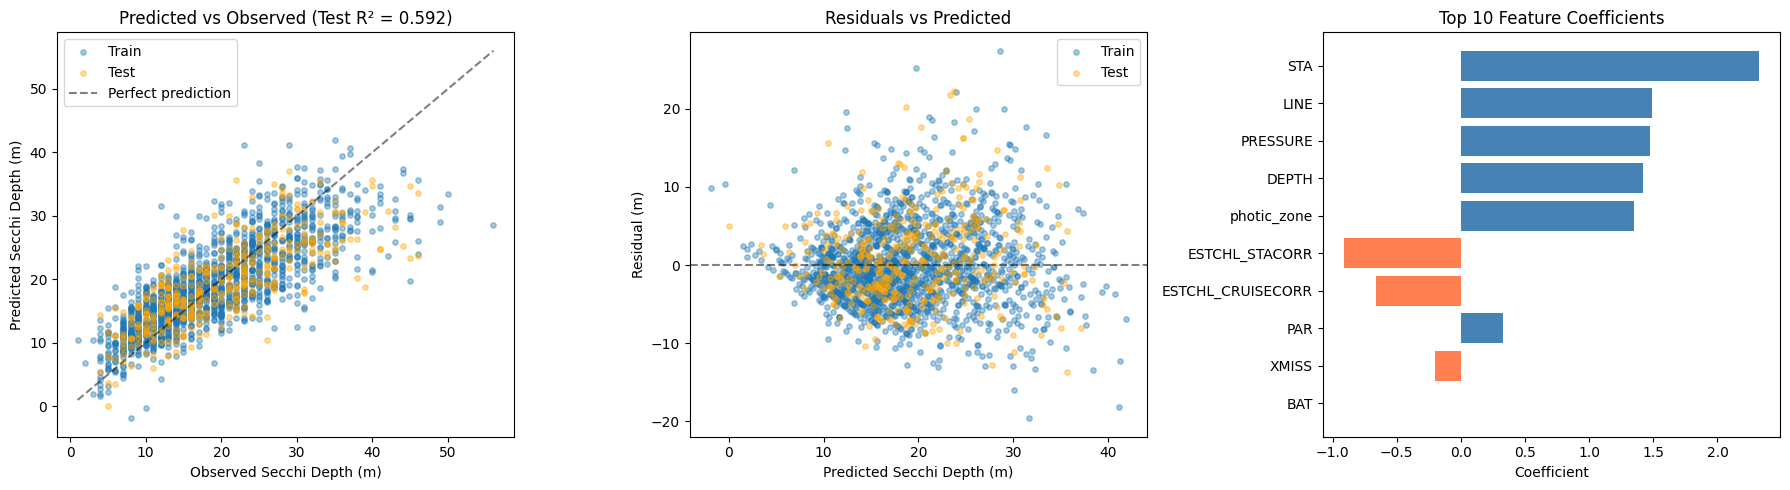

In [12]:
# STEP 6: Diagnostic Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicted vs Observed
axes[0].scatter(y_train, y_pred_train, alpha=0.4, label='Train', s=15)
axes[0].scatter(y_test, y_pred_test, alpha=0.4, label='Test', color='orange', s=15)
lims = [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())]
axes[0].plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
axes[0].set_xlabel('Observed Secchi Depth (m)')
axes[0].set_ylabel('Predicted Secchi Depth (m)')
axes[0].set_title(f'Predicted vs Observed (Test R² = {r2_score(y_test, y_pred_test):.3f})')
axes[0].legend()

# 2. Residual plot
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test
axes[1].scatter(y_pred_train, residuals_train, alpha=0.4, label='Train', s=15)
axes[1].scatter(y_pred_test, residuals_test, alpha=0.4, label='Test', color='orange', s=15)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Predicted Secchi Depth (m)')
axes[1].set_ylabel('Residual (m)')
axes[1].set_title('Residuals vs Predicted')
axes[1].legend()

# 3. Feature coefficient bar plot (top 10)
top10 = coef_df.head(10)
colors = ['steelblue' if c > 0 else 'coral' for c in top10['Coefficient']]
axes[2].barh(range(len(top10)), top10['Coefficient'].values, color=colors)
axes[2].set_yticks(range(len(top10)))
axes[2].set_yticklabels(top10['Feature'].values)
axes[2].set_xlabel('Coefficient')
axes[2].set_title('Top 10 Feature Coefficients')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()